#### **Underfitting and Overfitting with Linear Regression**

Linear Regression is used to predict a **continuous value** based on one or more input variables (features). The goal is to find the best line (or hyperplane) that describes the relationship between the input variables and the output variable.

#### **Simple Linear Regression (With a single Hyperplane)**

$y = \beta_0 + \beta_1 x + \epsilon$

Where:
* $y$ is the dependent variable (what we want to predict).
* $x$ is the independent variable (the feature).
* $\beta_0$ is the intercept (the value of $y$ when $x$ is 0).
* $\beta_1$ is the coefficient (the slope of the line, indicating how much $y$ changes when $x$ changes by one unit).
* $\epsilon$ is the random error (the noise in the data).

####**Multiple Linear Regression (Multiple Hyperplanes)**

$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n + \epsilon$

Where $x_1, x_2, ..., x_n$ are the different features and $\beta_1, \beta_2, ..., \beta_n$ are their respective coefficients.

The Linear Regression algorithm learns the values of $\beta_0$ and $\beta_1$ (or $\beta_0, \beta_1, ..., \beta_n$) that minimize the sum of squared errors between the predicted values and the actual values.

In [ ]:
#Import Libs
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_blobs

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#Generate a Synthetic Dataset ( Dataframe ) to Apply Linear Regression
np.random.seed(0)
X = np.linspace(0, 10, 100)
np.random.shuffle(X)

In [ ]:
#Show the Dataset
print(X)

[ 2.62626263  8.68686869  0.2020202   5.55555556  7.57575758  9.39393939
  1.61616162  7.37373737  5.45454545  9.5959596   5.35353535  9.29292929
  7.87878788  1.31313131  0.70707071  3.03030303  2.22222222  2.42424242
  3.33333333  0.80808081  4.34343434  6.26262626  0.3030303   7.17171717
  4.54545455  4.84848485  0.60606061 10.          8.28282828  7.67676768
  6.06060606  8.08080808  9.09090909  6.86868687  5.15151515  2.72727273
  1.81818182  5.65656566  6.36363636  7.47474747  0.1010101   6.16161616
  4.24242424  4.14141414  0.4040404   1.51515152  1.71717172  4.04040404
  3.83838384  0.50505051  9.19191919  5.95959596  0.          3.43434343
  2.82828283  5.05050505  1.11111111  3.53535354  2.32323232  5.25252525
  1.01010101  3.13131313  6.66666667  5.75757576  7.97979798  8.58585859
  3.23232323  8.48484848  1.41414141  8.98989899  1.91919192  2.92929293
  4.94949495  9.7979798   9.8989899   6.96969697  2.02020202  9.49494949
  7.27272727  7.77777778  2.52525253  3.73737374  8

In [ ]:
#Create the Classifiers ( Y ) with Noise
noise = np.random.randn(100) * 2
y = 2 * X + 1 + noise

In [ ]:
#Show the Results
print(y)

[ 7.10331205 18.31779501  4.35602007 13.40467131 15.42284653 18.43032401
  3.52506752 14.26597981 10.55904725 19.92635068 12.94667283 23.16819551
 17.09957663  0.17491992  2.73545849  5.34263542  5.03160256  6.82533778
  5.99000474  3.37848911  7.70506212 15.56101262  2.2892354  12.84166191
 11.94141059  8.88739738  5.89950427 24.05101448 14.6745854  17.10785658
 12.98009766 18.36993558 20.12611618 16.37720832 13.11806954  5.28289971
  6.51148132 11.80391513 15.67447015 16.36406049  3.40130415 15.20302628
 10.69762649  9.28634996 -0.17223948  7.77509119  3.95219625  9.18749789
 10.73839957 -0.54387696 21.05927791  9.93896909 -1.14043001  7.45042963
  7.86571021  7.61489364  6.27067585 11.79785771  8.22922049 14.10644305
  4.85660767  6.94502532 12.40520662  8.53359388 17.13905741 18.40142493
  6.2930161  18.56724105  4.27280263 19.85016391  4.74688764  6.95838269
  9.02792899 21.1707349  21.51883433 15.75569018  1.15897269 22.87957041
 15.93117627 15.71382591  9.53101197  7.74657392 20

In [ ]:
#Rshape the Data Array to a DataFrame
X = X.reshape(-1, 1)

In [ ]:
#Show the Shapes
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (100, 1)
Shape of y: (100,)


In [ ]:
#Concatenate the DataFrame to Visualize
df = pd.DataFrame(np.hstack((X, y.reshape(-1, 1))), columns=['X', 'y'])

In [ ]:
#Show the Dataframe
print(df)

           X          y
0   2.626263   7.103312
1   8.686869  18.317795
2   0.202020   4.356020
3   5.555556  13.404671
4   7.575758  15.422847
..       ...        ...
95  9.696970  21.616147
96  6.767677  12.780627
97  6.464646  10.687118
98  4.747475   9.331604
99  4.444444   8.813221

[100 rows x 2 columns]


In [ ]:
#Create a Linear Regression Model
model = LinearRegression()

In [ ]:
#Fit the linear regression model to the synthetic data X and y.
model.fit(X, y);

In [ ]:
# Generate predictions using the fitted model on the feature data X.
y_pred = model.predict(X)

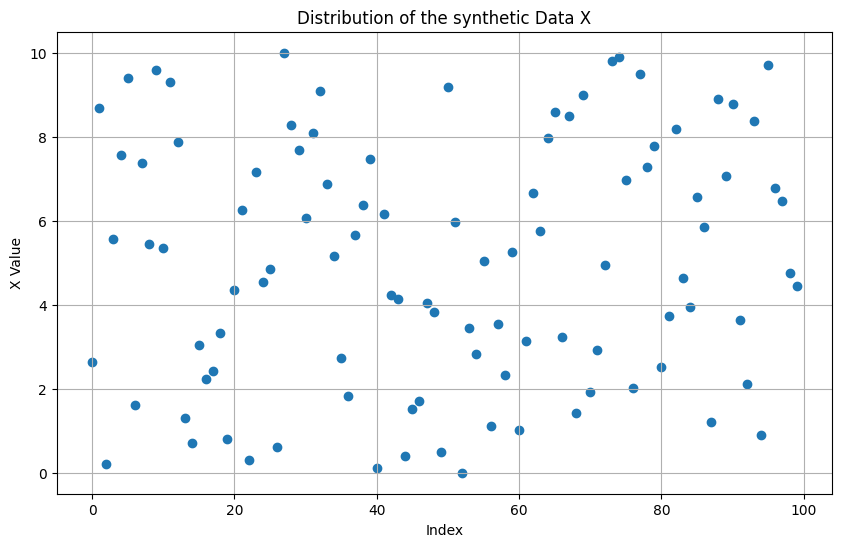

In [ ]:
# Plot the Distribution of the synthetic data X
plt.figure(figsize=(10, 6))
plt.scatter(range(len(X)), X)
plt.title('Distribution of the synthetic Data X')
plt.xlabel('Index')
plt.ylabel('X Value')
plt.grid(True)
plt.show()

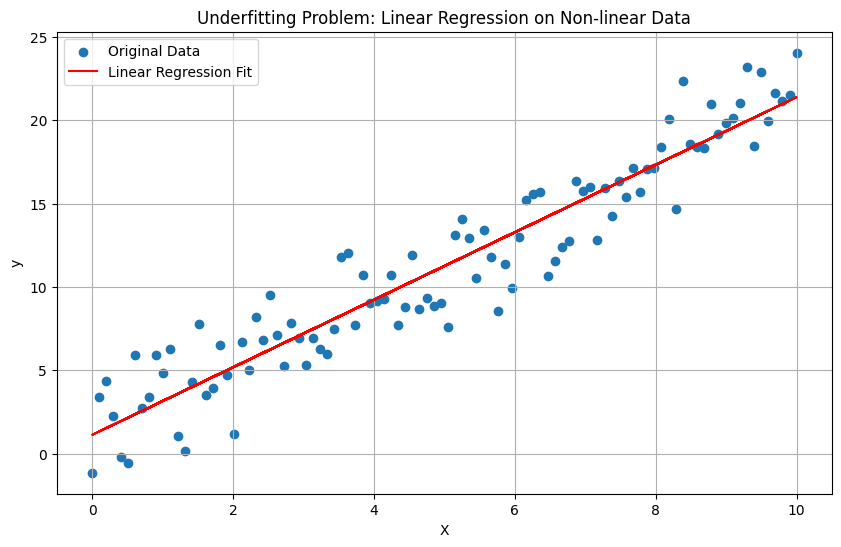

In [ ]:
#Plot the Data with a Line of Linear Regression.
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Original Data')
plt.plot(X, y_pred, color='red', label='Linear Regression Fit')
plt.title('Underfitting Problem: Linear Regression on Non-linear Data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

#### **Underfitting**

**Underfitting** occurs when a machine learning model is **too simple** to capture the patterns and complexity of the training data. It's like trying to fit a straight line to data that clearly follows a curve.

**Characteristics of Underfitting:**

* The model has **low performance** on both training data and new data (test).
* It fails to capture the underlying relationship in the data.
* It indicates that the model needs to be more complex or that relevant features are missing.

In [ ]:
#Example with Polynomial Regression
degree = 15
poly_features = PolynomialFeatures(degree=degree, include_bias=False)

In [ ]:
#Create a New Model of Polynomial Regression
new_model = make_pipeline(poly_features, LinearRegression())
new_model.fit(X, y);

In [ ]:
#Generate a Predict Model
y_pred = new_model.predict(X)

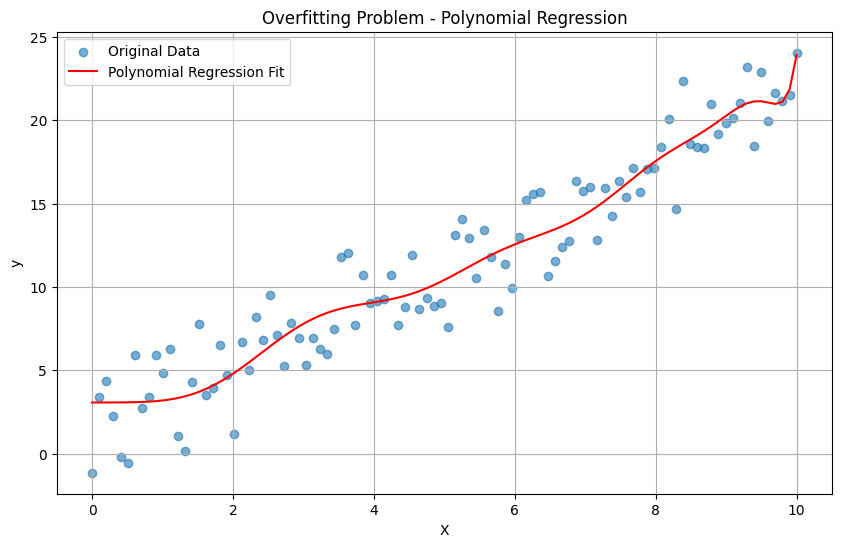

In [ ]:
# Show the Results.
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Original Data', alpha=0.6)

# Sort X before plotting the curve to ensure a smooth line
X_sorted = np.sort(X, axis=0)
y_pred_overfitting_sorted = new_model.predict(X_sorted)

plt.plot(X_sorted, y_pred_overfitting_sorted, color='red', label=f'Polynomial Regression Fit')
plt.title(f'Overfitting Problem - Polynomial Regression')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

#### **Overfitting**

**Overfitting** happens when the model is excessively complex and fits not only the pattern of the training data but also the random noise and specific variations of that data.

**Characteristics of Overfitting:**

* **Complex Model and Noise Fitting:** The model does not distinguish between the real signal and the noise in the training data. It memorizes the training points instead of learning the general relationship.
* **Poor Generalization:** Although the model has almost perfect performance on the training data (the curve passes very close to the points), it will not capture the true underlying relationship and will perform very poorly on new data it hasn't seen during training. The curve will likely behave erratically outside the range of the training data.